## Conhecendo os dados

In [2]:
!pip install scikit-learn==1.3.2

In [3]:
url1 = 'https://raw.githubusercontent.com/alura-cursos/combina-classificadores/main/dados/train.csv'
url2 = 'https://raw.githubusercontent.com/alura-cursos/combina-classificadores/main/dados/test.csv'

In [4]:
import pandas as pd

In [5]:
treino = pd.read_csv(url1)
teste = pd.read_csv(url2)

In [6]:
treino.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [7]:
treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [8]:
treino.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [9]:
def prepara(df):
  df.drop(columns = ['Unnamed: 0','id'], inplace=True)
  df.dropna(inplace=True)
  colunas_categoricas = ["Gender", "Customer Type", "Type of Travel", "Class"]
  df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)
  X = df.drop(columns='satisfaction')
  y = df['satisfaction']

  return X,y

In [10]:
X_treino, y_treino = prepara(treino)
X_teste, y_teste = prepara(teste)

In [11]:
X_treino

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,18.0,0,1,1,0,0,1,0,0,1
1,25,235,3,2,3,3,1,3,1,1,...,6.0,0,1,0,1,1,0,1,0,0
2,26,1142,2,2,2,2,5,5,5,5,...,0.0,1,0,1,0,1,0,1,0,0
3,25,562,2,5,5,5,2,2,2,2,...,9.0,1,0,1,0,1,0,1,0,0
4,61,214,3,3,3,3,4,5,5,3,...,0.0,0,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,23,192,2,1,2,3,2,2,2,2,...,0.0,1,0,0,1,1,0,0,1,0
103900,49,2347,4,4,4,4,2,4,5,5,...,0.0,0,1,1,0,1,0,1,0,0
103901,30,1995,1,1,1,3,4,1,5,4,...,14.0,0,1,0,1,1,0,1,0,0
103902,22,1000,1,1,1,5,1,1,1,1,...,0.0,1,0,0,1,1,0,0,1,0


### Testando as árvores

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

In [13]:
modelo_1 = DecisionTreeClassifier(random_state=42)

In [14]:
validacao = cross_validate(modelo_1, X_treino, y_treino, cv=5)

In [15]:
validacao['test_score'].mean()

0.9443500672495754

In [16]:
modelo_1.fit(X_treino, y_treino)

DecisionTreeClassifier(random_state=42)

In [17]:
y_pred = modelo_1.predict(X_teste)
print(f'socre: {modelo_1.score(X_teste, y_teste)}')

socre: 0.94612443517553


## Pipeline

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
modelo_2 = LogisticRegression(random_state=42)
validacao = cross_validate(modelo_2, X_treino, y_treino, cv=5)
validacao['test_score'].mean()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.8186670972160262

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [21]:
pipeline = Pipeline([
    ('Scaler', StandardScaler()),
    ('Modelo', modelo_2)
])

In [22]:
validacao = cross_validate(pipeline, X_treino, y_treino, cv=5)
validacao['test_score'].mean()

0.8749541859894492

## Votação

In [23]:
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
modelo_3 = GaussianNB()

In [25]:
nome_modelos = ['Árvores', 'Logística','Naive Bayes']

In [26]:
pipelines = []

for modelo, nome in zip([modelo_1,modelo_2,modelo_3],nome_modelos):

  pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalização dos dados
    ('model', modelo)
  ])

  validacao = cross_validate(pipeline, X_treino, y_treino, cv=5)
  pipelines.append(pipeline)

  print(validacao['test_score'].mean())

0.9443983339909126
0.8749541859894492
0.8483406855152964


In [27]:
votacao = VotingClassifier(estimators=[(nome_modelos[0], pipelines[0]),
                                       (nome_modelos[1], pipelines[1]),
                                       (nome_modelos[2], pipelines[2])],
                           voting='hard')

In [28]:
votacao

VotingClassifier(estimators=[('Árvores',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               DecisionTreeClassifier(random_state=42))])),
                             ('Logística',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               LogisticRegression(random_state=42))])),
                             ('Naive Bayes',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model', GaussianNB())]))])

In [29]:
validacao = cross_validate(votacao, X_treino, y_treino, cv=5)
validacao['test_score'].mean()

0.8917601803912731

### Votação SOFT

In [30]:
votacao = VotingClassifier(estimators=[(nome_modelos[0], pipelines[0]),
                                       (nome_modelos[1], pipelines[1]),
                                       (nome_modelos[2], pipelines[2])],
                           voting='soft')

In [31]:
validacao = cross_validate(votacao, X_treino, y_treino, cv=5)

In [32]:
validacao['test_score'].mean()

0.9007375478071673

### Tunando a votação

In [33]:
parametros = {
    'voting':['hard','soft'],
    'weights': [(1,1,1),(2,1,1),(1,2,1),(1,1,2)]
}

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
gridsearch = GridSearchCV(votacao, param_grid=parametros, n_jobs=-1)

gridsearch.fit(X_treino, y_treino)

GridSearchCV(estimator=VotingClassifier(estimators=[('Árvores',
                                                     Pipeline(steps=[('scaler',
                                                                      StandardScaler()),
                                                                     ('model',
                                                                      DecisionTreeClassifier(random_state=42))])),
                                                    ('Logística',
                                                     Pipeline(steps=[('scaler',
                                                                      StandardScaler()),
                                                                     ('model',
                                                                      LogisticRegression(random_state=42))])),
                                                    ('Naive Bayes',
                                                     Pipeline(steps=[('scaler',
                                                                      StandardScaler()),
                                                                     ('model',
                                                                      GaussianNB())]))],
                                        voting='soft'),
             n_jobs=-1,
             param_grid={'voting': ['hard', 'soft'],
                         'weights': [(1, 1, 1), (2, 1, 1), (1, 2, 1),
                                     (1, 1, 2)]})

In [36]:
resultados = pd.DataFrame(gridsearch.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_voting,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.378376,0.306470,0.258349,0.037024,hard,"(1, 1, 1)","{'voting': 'hard', 'weights': (1, 1, 1)}",0.889763,0.891356,0.889280,0.892514,0.895888,0.891760,0.002362,5
1,1.091592,0.033472,0.222075,0.011131,hard,"(2, 1, 1)","{'voting': 'hard', 'weights': (2, 1, 1)}",0.916840,0.920122,0.919349,0.920315,0.924558,0.920237,0.002491,2
2,1.080790,0.021275,0.229975,0.011404,hard,"(1, 2, 1)","{'voting': 'hard', 'weights': (1, 2, 1)}",0.880158,0.881896,0.880351,0.883296,0.887151,0.882570,0.002558,6
3,1.206459,0.153351,0.298263,0.097886,hard,"(1, 1, 2)","{'voting': 'hard', 'weights': (1, 1, 2)}",0.872484,0.875428,0.874608,0.877600,0.880925,0.876209,0.002871,7
4,1.221678,0.160146,0.063772,0.001461,soft,"(1, 1, 1)","{'voting': 'soft', 'weights': (1, 1, 1)}",0.898644,0.898499,0.898644,0.901636,0.906265,0.900738,0.003005,3
5,1.123063,0.029357,0.067203,0.007681,soft,"(2, 1, 1)","{'voting': 'soft', 'weights': (2, 1, 1)}",0.941841,0.945895,0.945219,0.943627,0.945410,0.944398,0.001488,1
6,1.103790,0.011719,0.061948,0.001879,soft,"(1, 2, 1)","{'voting': 'soft', 'weights': (1, 2, 1)}",0.895169,0.895844,0.894445,0.898161,0.901921,0.897108,0.002710,4
7,1.371283,0.242006,0.075914,0.026421,soft,"(1, 1, 2)","{'voting': 'soft', 'weights': (1, 1, 2)}",0.868623,0.870843,0.868333,0.871760,0.877015,0.871315,0.003132,8


In [37]:
gridsearch.best_params_

{'voting': 'soft', 'weights': (2, 1, 1)}

In [38]:
y_pred = gridsearch.predict(X_teste)

In [39]:
from sklearn.metrics import classification_report

metricas = classification_report(y_teste, y_pred)
print(metricas)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.95      0.95     14528
              satisfied       0.94      0.94      0.94     11365

               accuracy                           0.95     25893
              macro avg       0.95      0.95      0.95     25893
           weighted avg       0.95      0.95      0.95     25893



## Bagging

### BaggingClassifier

In [40]:
from sklearn.ensemble import BaggingClassifier

In [41]:
bagging_classifier = BaggingClassifier(n_estimators=10, random_state=42)

bagging_classifier.fit(X_treino, y_treino)

BaggingClassifier(random_state=42)

In [42]:
y_pred = bagging_classifier.predict(X_teste)

In [43]:
metricas = classification_report(y_teste, y_pred)
print(metricas)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.98      0.96     14528
              satisfied       0.97      0.94      0.95     11365

               accuracy                           0.96     25893
              macro avg       0.96      0.96      0.96     25893
           weighted avg       0.96      0.96      0.96     25893



### Validando o Bagging

In [44]:
modelo_base = pipelines[0]

In [45]:
parametros = {
    'n_estimators': [10,20,30],
    'max_samples': [0.5,0.7,0.9],
    'max_features': [0.5,0.7,0.9]
}

In [46]:
bagging_grid = GridSearchCV(
    BaggingClassifier(),
    param_grid=parametros,
    cv=5,
    n_jobs=-1
)

In [47]:
bagging_grid.fit(X_treino, y_treino)

GridSearchCV(cv=5, estimator=BaggingClassifier(), n_jobs=-1,
             param_grid={'max_features': [0.5, 0.7, 0.9],
                         'max_samples': [0.5, 0.7, 0.9],
                         'n_estimators': [10, 20, 30]})

In [48]:
melhores_parametros = bagging_grid.best_params_

In [49]:
resultados = pd.DataFrame(bagging_grid.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_samples,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.988997,0.272250,0.094620,0.019762,0.5,0.5,10,"{'max_features': 0.5, 'max_samples': 0.5, 'n_e...",0.941744,0.946571,0.943627,0.946571,0.949561,0.945615,0.002696,27
1,3.382414,0.301633,0.127947,0.029093,0.5,0.5,20,"{'max_features': 0.5, 'max_samples': 0.5, 'n_e...",0.956175,0.946426,0.951204,0.953473,0.955739,0.952603,0.003563,24
2,5.245971,0.391813,0.147964,0.003551,0.5,0.5,30,"{'max_features': 0.5, 'max_samples': 0.5, 'n_e...",0.950770,0.956079,0.952797,0.953473,0.957573,0.954138,0.002415,20
3,2.244037,0.411926,0.081216,0.002223,0.5,0.7,10,"{'max_features': 0.5, 'max_samples': 0.7, 'n_e...",0.950239,0.951204,0.947826,0.951011,0.942465,0.948549,0.003271,25
4,4.250491,0.399803,0.131895,0.025361,0.5,0.7,20,"{'max_features': 0.5, 'max_samples': 0.7, 'n_e...",0.957720,0.953859,0.952073,0.950866,0.952215,0.953347,0.002385,22
5,6.616456,0.325441,0.164436,0.020431,0.5,0.7,30,"{'max_features': 0.5, 'max_samples': 0.7, 'n_e...",0.954390,0.956562,0.953569,0.956465,0.953133,0.954824,0.001438,19
6,2.617441,0.389444,0.081992,0.002343,0.5,0.9,10,"{'max_features': 0.5, 'max_samples': 0.9, 'n_e...",0.943385,0.948936,0.938993,0.946185,0.952119,0.945924,0.004517,26
7,5.296129,0.169315,0.134931,0.030511,0.5,0.9,20,"{'max_features': 0.5, 'max_samples': 0.9, 'n_e...",0.953328,0.955500,0.955934,0.943675,0.956415,0.952970,0.004766,23
8,7.338423,0.537805,0.179224,0.034543,0.5,0.9,30,"{'max_features': 0.5, 'max_samples': 0.9, 'n_e...",0.955065,0.956369,0.950722,0.957527,0.959021,0.955741,0.002828,18
9,2.314959,0.329807,0.075982,0.001307,0.7,0.5,10,"{'max_features': 0.7, 'max_samples': 0.5, 'n_e...",0.948936,0.959651,0.956562,0.947391,0.957814,0.954071,0.004946,21


In [50]:
bagging_classifier = BaggingClassifier(estimator=modelo_base, **melhores_parametros)

In [51]:
bagging_classifier.fit(X_treino, y_treino)

BaggingClassifier(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                            ('model',
                                             DecisionTreeClassifier(random_state=42))]),
                  max_features=0.9, max_samples=0.7, n_estimators=30)

In [52]:
y_pred = bagging_classifier.predict(X_teste)

In [53]:
resultados = classification_report(y_teste, y_pred)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14528
              satisfied       0.97      0.94      0.96     11365

               accuracy                           0.96     25893
              macro avg       0.96      0.96      0.96     25893
           weighted avg       0.96      0.96      0.96     25893



### ExtraTreesClassifier

In [54]:
parametros = {
    'n_estimators': [10,20,30],
    'max_features': [0.5,0.7,0.9]
}

In [55]:
from sklearn.ensemble import ExtraTreesClassifier

In [56]:
extra_trees_grid = GridSearchCV(
    ExtraTreesClassifier(),
    param_grid=parametros,
    cv=5,
    n_jobs=-1
)

In [57]:
extra_trees_grid.fit(X_treino, y_treino)

GridSearchCV(cv=5, estimator=ExtraTreesClassifier(), n_jobs=-1,
             param_grid={'max_features': [0.5, 0.7, 0.9],
                         'n_estimators': [10, 20, 30]})

In [58]:
resultados = pd.DataFrame(extra_trees_grid.cv_results_)
resultados

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.768456,0.048334,0.077120,0.003324,0.5,10,"{'max_features': 0.5, 'n_estimators': 10}",0.957961,0.961050,0.959361,0.959602,0.961435,0.959882,0.001250,9
1,3.850643,0.399077,0.111735,0.003857,0.5,20,"{'max_features': 0.5, 'n_estimators': 20}",0.961243,0.961774,0.960471,0.962740,0.963269,0.961899,0.001007,5
2,5.490407,0.440364,0.176582,0.056793,0.5,30,"{'max_features': 0.5, 'n_estimators': 30}",0.961436,0.963174,0.961388,0.963222,0.963558,0.962556,0.000943,3
3,2.661030,0.359970,0.082769,0.013549,0.7,10,"{'max_features': 0.7, 'n_estimators': 10}",0.959361,0.962064,0.959071,0.961726,0.961531,0.960751,0.001268,8
4,4.788685,0.382572,0.132251,0.032414,0.7,20,"{'max_features': 0.7, 'n_estimators': 20}",0.960761,0.961581,0.960761,0.962595,0.963269,0.961793,0.001000,6
5,6.923820,0.257492,0.182779,0.072681,0.7,30,"{'max_features': 0.7, 'n_estimators': 30}",0.962353,0.962981,0.961436,0.964381,0.963848,0.963000,0.001048,1
6,3.227247,0.350392,0.076069,0.002534,0.9,10,"{'max_features': 0.9, 'n_estimators': 10}",0.960085,0.963077,0.959554,0.961099,0.961241,0.961011,0.001209,7
7,6.112916,0.323344,0.126927,0.029021,0.9,20,"{'max_features': 0.9, 'n_estimators': 20}",0.962112,0.963270,0.961774,0.962691,0.961676,0.962305,0.000599,4
8,8.951423,0.490237,0.157768,0.057897,0.9,30,"{'max_features': 0.9, 'n_estimators': 30}",0.961485,0.963898,0.961919,0.963126,0.963944,0.962874,0.001010,2


In [59]:
melhores_parametros = extra_trees_grid.best_params_

In [60]:
extratrees_classifier = ExtraTreesClassifier(**melhores_parametros)

In [61]:
extratrees_classifier.fit(X_treino, y_treino)

ExtraTreesClassifier(max_features=0.7, n_estimators=30)

In [62]:
y_pred_tree = extratrees_classifier.predict(X_teste)

In [63]:
resultados = classification_report(y_teste, y_pred_tree)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14528
              satisfied       0.97      0.94      0.96     11365

               accuracy                           0.96     25893
              macro avg       0.96      0.96      0.96     25893
           weighted avg       0.96      0.96      0.96     25893



In [64]:
extra_trees_grid.best_score_

0.9629997958189271

## Boosting

### AdaBoost

In [65]:
from sklearn.ensemble import AdaBoostClassifier

In [66]:
modelo = AdaBoostClassifier(n_estimators=50, learning_rate=1)

modelo.fit(X_treino, y_treino)

AdaBoostClassifier(learning_rate=1)

In [67]:
y_pred_ada = modelo.predict(X_teste)

In [68]:
resultados = classification_report(y_teste, y_pred_ada)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.93      0.94      0.93     14528
              satisfied       0.92      0.91      0.92     11365

               accuracy                           0.93     25893
              macro avg       0.93      0.92      0.93     25893
           weighted avg       0.93      0.93      0.93     25893



### Parâmetros do AdaBoost

In [69]:
param_grid = {
'n_estimators': [50,100,200],
'learning_rate': [0.1,0.01,0.001]
}

In [70]:
adaboost_classifier = AdaBoostClassifier()

In [71]:
gridsearchada = GridSearchCV(
    AdaBoostClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [72]:
gridsearchada.fit(X_treino, y_treino)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [73]:
y_pred = gridsearchada.predict(X_teste)

In [74]:
resultados = classification_report(y_teste, y_pred)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.92      0.94      0.93     14528
              satisfied       0.93      0.90      0.91     11365

               accuracy                           0.92     25893
              macro avg       0.92      0.92      0.92     25893
           weighted avg       0.92      0.92      0.92     25893



In [75]:
gridsearchada.best_score_

0.9258161725228913

### CatBoost

In [76]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.6 MB/s eta 0:00:00


In [77]:
from catboost import CatBoostClassifier

In [78]:
param_grid = {
'iterations': [100, 200,300],
'depth': [4,6,8],
'learning_rate': [0.1,0.01,0.001]
}

In [79]:
grid_search = GridSearchCV(estimator=CatBoostClassifier(verbose=0),param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

In [80]:
grid_search.fit(X_treino,y_treino)

GridSearchCV(cv=5, estimator=CatBoostClassifier(verbose=0), n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200, 300],
                         'learning_rate': [0.1, 0.01, 0.001]},
             scoring='accuracy')

In [81]:
y_pred_cat = grid_search.predict(X_teste)

In [82]:
resultados = classification_report(y_teste, y_pred_cat)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14528
              satisfied       0.97      0.95      0.96     11365

               accuracy                           0.96     25893
              macro avg       0.97      0.96      0.96     25893
           weighted avg       0.96      0.96      0.96     25893



## Stacking

### StackingClassifier

In [83]:
from sklearn.ensemble import StackingClassifier

In [84]:
modelos_base = [(nome_modelos[0], pipelines[0]),
           (nome_modelos[1], pipelines[1]),
           (nome_modelos[2], pipelines[2])]

In [85]:
modelos_base

[('Árvores',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model', DecisionTreeClassifier(random_state=42))])),
 ('Logística',
  Pipeline(steps=[('scaler', StandardScaler()),
                  ('model', LogisticRegression(random_state=42))])),
 ('Naive Bayes',
  Pipeline(steps=[('scaler', StandardScaler()), ('model', GaussianNB())]))]

In [86]:
modelo_meta = LogisticRegression(random_state=42)

In [87]:
stacking_classifier = StackingClassifier(estimators=modelos_base, final_estimator=modelo_meta)

In [88]:
stacking_classifier.fit(X_treino, y_treino)

StackingClassifier(estimators=[('Árvores',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 DecisionTreeClassifier(random_state=42))])),
                               ('Logística',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(random_state=42))])),
                               ('Naive Bayes',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model', GaussianNB())]))],
                   final_estimator=LogisticRegression(random_state=42))

In [89]:
y_pred = stacking_classifier.predict(X_teste)

In [90]:
resultados = classification_report(y_teste, y_pred)
print(resultados)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.95      0.95      0.95     14528
              satisfied       0.94      0.94      0.94     11365

               accuracy                           0.95     25893
              macro avg       0.95      0.95      0.95     25893
           weighted avg       0.95      0.95      0.95     25893



### Validando o Stacking

In [91]:
!pip install mlxtend

In [92]:
from mlxtend.classifier import StackingCVClassifier

In [93]:
parametros_cat = grid_search.best_params_

In [94]:
parametros_trees = extra_trees_grid.best_params_

In [95]:
base_models = [
    CatBoostClassifier(**parametros_cat),
    ExtraTreesClassifier(**parametros_trees),
    pipelines[2]
]

In [96]:
base_models

[CatBoostClassifier(depth=8, iterations=300, learning_rate=0.1),
 ExtraTreesClassifier(max_features=0.7, n_estimators=30),
 Pipeline(steps=[('scaler', StandardScaler()), ('model', GaussianNB())])]

In [97]:
stacking_cv_classifier = StackingCVClassifier(classifiers=base_models, meta_classifier=modelo_meta)

In [98]:
mapeamento = {'neutral or dissatisfied': 0, 'satisfied': 1}

In [99]:
y_treino = y_treino.replace(mapeamento)

/tmp/ipykernel_731/1797420716.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_treino = y_treino.replace(mapeamento)


In [100]:
y_teste = y_teste.replace(mapeamento)

/tmp/ipykernel_731/1345879902.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_teste = y_teste.replace(mapeamento)


In [101]:
stacking_cv_classifier.fit(X_treino, y_treino)

0:	learn: 0.5431074	total: 42.1ms	remaining: 12.6s
1:	learn: 0.4489424	total: 85.1ms	remaining: 12.7s
2:	learn: 0.3474330	total: 161ms	remaining: 16s
3:	learn: 0.3035454	total: 211ms	remaining: 15.6s
4:	learn: 0.2540499	total: 288ms	remaining: 17s
5:	learn: 0.2293951	total: 346ms	remaining: 16.9s
6:	learn: 0.2088092	total: 411ms	remaining: 17.2s
7:	learn: 0.1919578	total: 504ms	remaining: 18.4s
8:	learn: 0.1809374	total: 554ms	remaining: 17.9s
9:	learn: 0.1705328	total: 593ms	remaining: 17.2s
10:	learn: 0.1654021	total: 627ms	remaining: 16.5s
11:	learn: 0.1591456	total: 668ms	remaining: 16s
12:	learn: 0.1514283	total: 714ms	remaining: 15.8s
13:	learn: 0.1469537	total: 751ms	remaining: 15.3s
14:	learn: 0.1429431	total: 769ms	remaining: 14.6s
15:	learn: 0.1399901	total: 791ms	remaining: 14s
16:	learn: 0.1368072	total: 810ms	remaining: 13.5s
17:	learn: 0.1344967	total: 826ms	remaining: 12.9s
18:	learn: 0.1320688	total: 847ms	remaining: 12.5s
19:	learn: 0.1293754	total: 883ms	remaining: 12

StackingCVClassifier(classifiers=[CatBoostClassifier(depth=8, iterations=300, learning_rate=0.1),
                                  ExtraTreesClassifier(max_features=0.7,
                                                       n_estimators=30),
                                  Pipeline(steps=[('scaler', StandardScaler()),
                                                  ('model', GaussianNB())])],
                     meta_classifier=LogisticRegression(random_state=42))

In [102]:
y_pred = stacking_cv_classifier.predict(X_teste)
resultados = classification_report(y_teste, y_pred)
print(resultados)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.95      0.96     11365

    accuracy                           0.96     25893
   macro avg       0.96      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893



### Analisando resultados

In [103]:
validacao = cross_validate(stacking_cv_classifier, X_treino, y_treino, cv=5, n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [104]:
validacao['test_score']

array([0.96230513, 0.96467011, 0.96225687, 0.96549061, 0.96524761])

In [105]:
validacao['test_score'].mean()

0.96399406581023

In [106]:
from mlxtend.evaluate import scoring

In [107]:
scoring(y_target=y_teste, y_predicted=y_pred, metric='error')

0.036226007028926754

In [108]:
scoring(y_target=y_teste, y_predicted=y_pred, metric='precision')

0.9697270024326516

In [109]:
scoring(y_target=y_teste, y_predicted=y_pred, metric='recall')

0.9470303563572371

In [110]:
scoring(y_target=y_teste, y_predicted=y_pred, metric='f1')

0.958244301994302

In [111]:
from mlxtend.plotting import plot_confusion_matrix
from mlxtend.evaluate import confusion_matrix

In [112]:
matriz_confusao = confusion_matrix(y_teste, y_pred)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

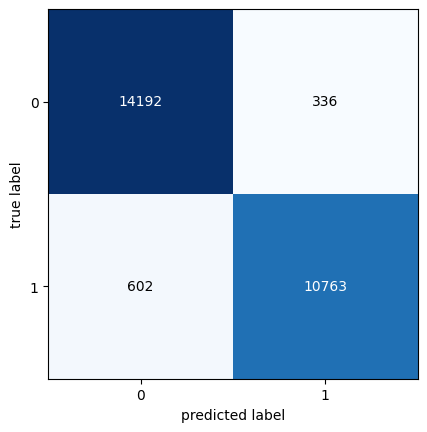

In [113]:
plot_confusion_matrix(conf_mat=matriz_confusao)

In [114]:
import joblib

In [115]:
joblib.dump(stacking_cv_classifier, 'modelo_treinado.pkl')

['modelo_treinado.pkl']

In [116]:
modelo_carregado = joblib.load('modelo_treinado.pkl')

In [117]:
previsao = modelo_carregado.predict([X_teste.iloc[2]])

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
